In [2]:
import pandas as pd

train_df = pd.read_csv(
    "file:///C:/Users/hp/Downloads/Genre%20Classification%20Dataset/train_data.txt",
    sep=" ::: ",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"],
    engine="python",
    encoding="utf-8"
)

print(train_df.head())
print(train_df.shape)



   ID                             TITLE     GENRE  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   
3   4             The Secret Sin (1915)     drama   
4   5            The Unrecovered (2007)     drama   

                                         DESCRIPTION  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  
(54214, 4)


In [3]:
test_df = pd.read_csv(
    "file:///C:/Users/hp/Downloads/Genre%20Classification%20Dataset/test_data.txt",
    sep=" ::: ",
    names=["ID", "TITLE", "DESCRIPTION"],
    engine="python",
    encoding="utf-8"
)

print(test_df.head())
print(test_df.shape)

   ID                        TITLE  \
0   1         Edgar's Lunch (1998)   
1   2     La guerra de papá (1977)   
2   3  Off the Beaten Track (2010)   
3   4       Meu Amigo Hindu (2015)   
4   5            Er nu zhai (1955)   

                                         DESCRIPTION  
0  L.R. Brane loves his life - his car, his apart...  
1  Spain, March 1964: Quico is a very naughty chi...  
2  One year in the life of Albin and his family o...  
3  His father has died, he hasn't spoken with his...  
4  Before he was known internationally as a marti...  
(54200, 3)


In [4]:
import pandas as pd
import numpy as np

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [7]:
def preprocess(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords and stem words
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [8]:
train_df["DESCRIPTION"] = train_df["DESCRIPTION"].apply(preprocess)

test_df["DESCRIPTION"] = test_df["DESCRIPTION"].apply(preprocess)

In [9]:
print(train_df["DESCRIPTION"].head())

0    listen convers doctor parent yearold oscar lea...
1    brother sister past incestu relationship curre...
2    bu empti student field trip museum natur histo...
3    help unemploy father make end meet edith twin ...
4    film titl refer unrecov bodi ground zero also ...
Name: DESCRIPTION, dtype: object


In [10]:
X = train_df["DESCRIPTION"]

y = train_df["GENRE"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_valid_tfidf = tfidf.transform(X_valid)

X_test_tfidf = tfidf.transform(test_df["DESCRIPTION"])

In [18]:
print(X_train_tfidf.shape)
print(X_valid_tfidf.shape)
print(X_test_tfidf.shape)

(43371, 30000)
(10843, 30000)
(54200, 30000)


In [19]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

pred = svm.predict(X_valid_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_valid, pred))

Linear SVM Accuracy: 0.5759476159734391


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, pred))

              precision    recall  f1-score   support

      action       0.42      0.33      0.37       263
       adult       0.65      0.44      0.53       118
   adventure       0.39      0.19      0.25       155
   animation       0.44      0.14      0.21       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.59      0.55      1490
       crime       0.33      0.08      0.13       101
 documentary       0.69      0.81      0.74      2619
       drama       0.56      0.70      0.62      2723
      family       0.32      0.14      0.19       157
     fantasy       0.27      0.06      0.10        65
   game-show       0.81      0.64      0.71        39
     history       0.43      0.06      0.11        49
      horror       0.63      0.63      0.63       441
       music       0.61      0.51      0.55       146
     musical       0.20      0.04      0.06        55
     mystery       0.07      0.02      0.03        64
        news       0.56    

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

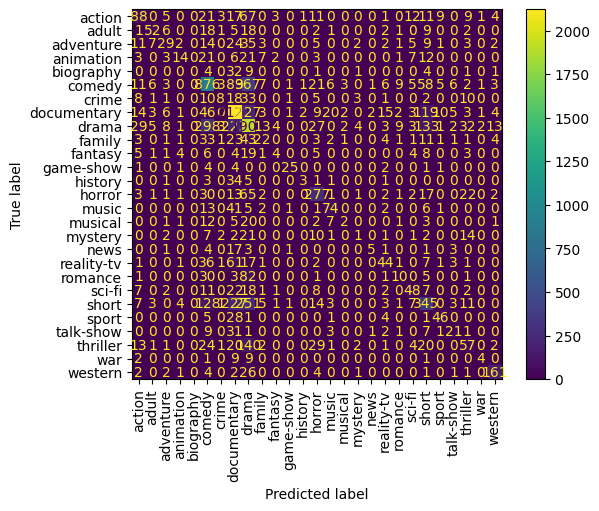

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_valid_tfidf,
    y_valid,
    xticks_rotation=90
)

plt.show()

In [22]:
import joblib

joblib.dump(svm, "movie_genre_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [23]:
test_predictions = svm.predict(X_test_tfidf)

test_df["Predicted_Genre"] = test_predictions

print(test_df.head())

   ID                        TITLE  \
0   1         Edgar's Lunch (1998)   
1   2     La guerra de papá (1977)   
2   3  Off the Beaten Track (2010)   
3   4       Meu Amigo Hindu (2015)   
4   5            Er nu zhai (1955)   

                                         DESCRIPTION Predicted_Genre  
0  lr brane love life car apart job especi girlfr...          comedy  
1  spain march quico naughti child three belong w...           drama  
2  one year life albin famili shepherd north tran...     documentary  
3  father die hasnt spoken brother year seriou ca...           drama  
4  known intern martial art superstar bruce lee a...           drama  


In [24]:
plot = """
A young wizard discovers magical powers and attends a school of magic
"""

plot = preprocess(plot)

vector = tfidf.transform([plot])

prediction = svm.predict(vector)

print("Predicted Genre:", prediction[0])

Predicted Genre: fantasy
